Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

Data Collection and Analysis

In [2]:
insurance_dataset = pd.read_csv('/content/insurance.csv')

In [3]:
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
insurance_dataset.shape

(1338, 7)

In [5]:
insurance_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
insurance_dataset.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


EDA

In [7]:
insurance_dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


/tmp/ipykernel_8131/215121745.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_dataset['age'])


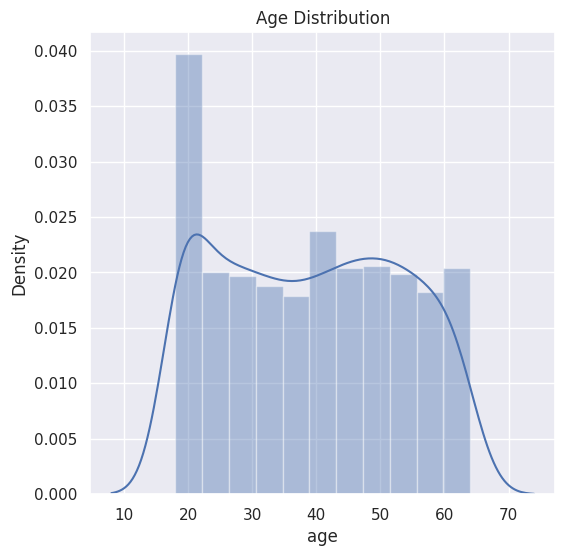

In [10]:
# Distribution of age value
sns.set()
plt.figure(figsize=(6,6))
sns.distplot(insurance_dataset['age'])
plt.title('Age Distribution')
plt.show()

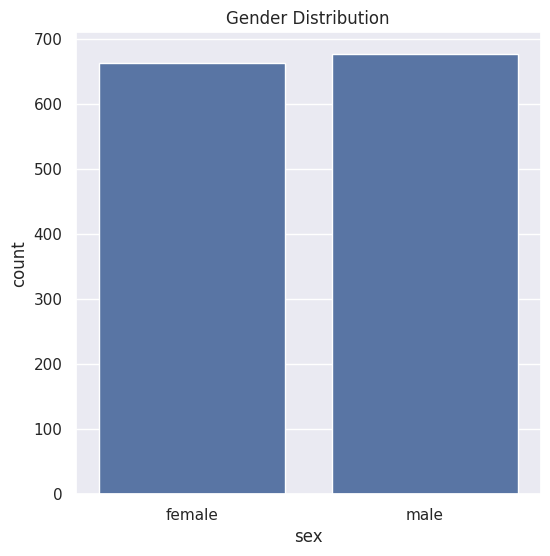

In [12]:
# Gender Column
plt.figure(figsize=(6,6))
sns.countplot(x='sex',data = insurance_dataset)
plt.title('Gender Distribution')
plt.show()

In [13]:
insurance_dataset['sex'].value_counts()

,count
sex,
male,676
female,662


/tmp/ipykernel_8131/289663240.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_dataset['bmi'])


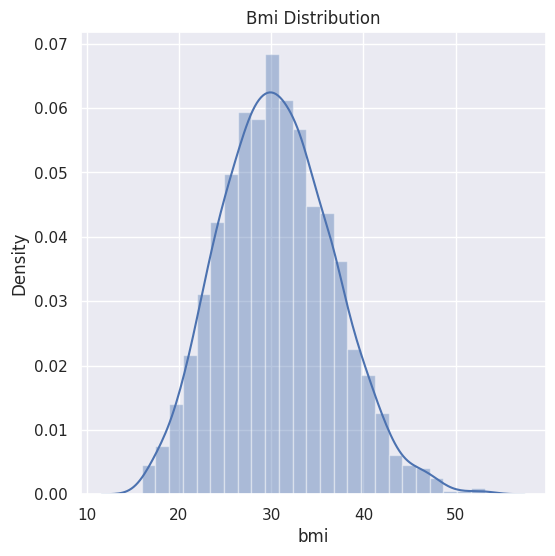

In [14]:
# Bmi Distribution
plt.figure(figsize=(6,6))
sns.distplot(insurance_dataset['bmi'])
plt.title('Bmi Distribution')
plt.show()

Normal Bmi Range --> 18.5 to 24.9

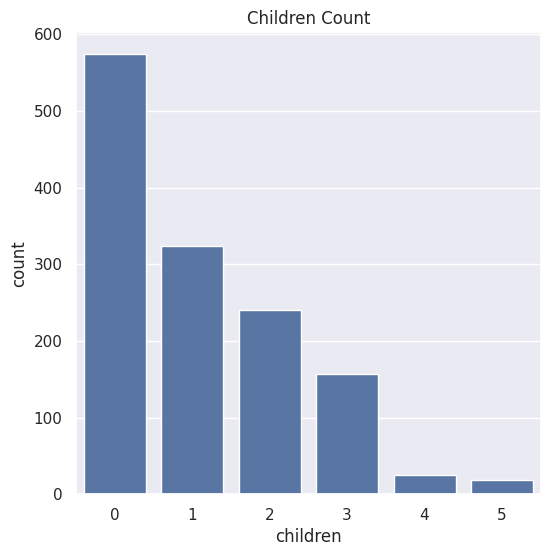

In [15]:
# Children Count
plt.figure(figsize=(6,6))
sns.countplot(x='children',data = insurance_dataset)
plt.title('Children Count')
plt.show()

In [16]:
insurance_dataset['children'].value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


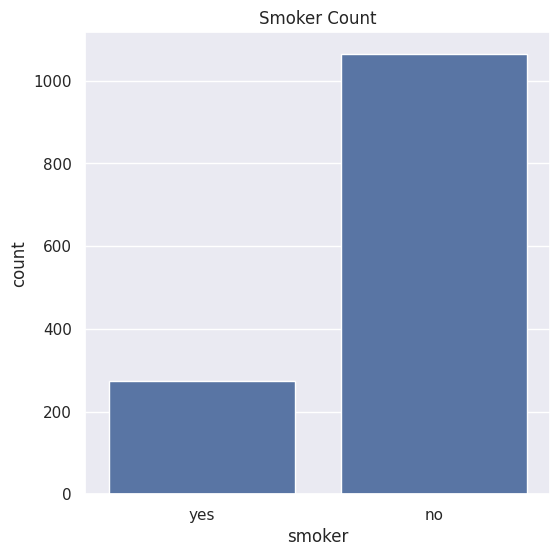

In [17]:
# Smoker column
plt.figure(figsize=(6,6))
sns.countplot(x='smoker',data = insurance_dataset)
plt.title('Smoker Count')
plt.show()

In [18]:
insurance_dataset['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


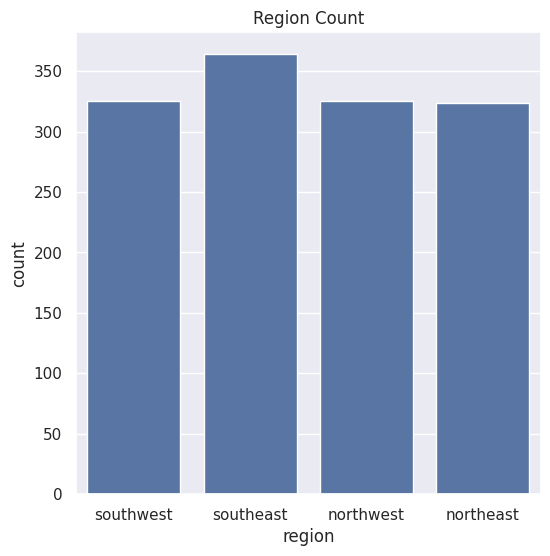

In [19]:
# Region
plt.figure(figsize=(6,6))
sns.countplot(x='region',data = insurance_dataset)
plt.title('Region Count')
plt.show()

In [20]:
insurance_dataset['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


/tmp/ipykernel_8131/449999553.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_dataset['charges'])


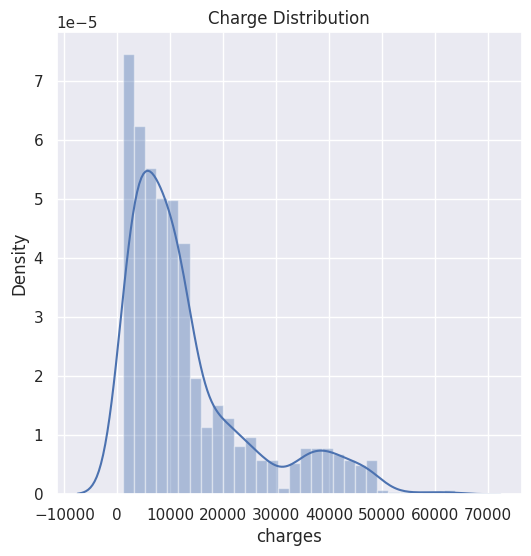

In [21]:
# Charges Distribution
plt.figure(figsize=(6,6))
sns.distplot(insurance_dataset['charges'])
plt.title('Charge Distribution')
plt.show()

Data Pre-Processing

Encoding

In [26]:
#Encoding Sex Column
insurance_dataset.replace({'sex':{'male':0, 'female':1}}, inplace=True)

#Encoding Smoker Column
insurance_dataset.replace({'smoker':{'yes':0, 'no':1}}, inplace=True)

#Encoding Region Column
insurance_dataset.replace({'region':{'southeast':0, 'southwest':1, 'northeast':2, 'northwest':3}}, inplace=True)



/tmp/ipykernel_8131/3862315271.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_dataset.replace({'sex':{'male':0, 'female':1}}, inplace=True)
/tmp/ipykernel_8131/3862315271.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_dataset.replace({'smoker':{'yes':0, 'no':1}}, inplace=True)
/tmp/ipykernel_8131/3862315271.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-

In [27]:
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,1,16884.92400
1,18,0,33.770,1,1,0,1725.55230
2,28,0,33.000,3,1,0,4449.46200
3,33,0,22.705,0,1,3,21984.47061
4,32,0,28.880,0,1,3,3866.85520


Spliting Features and Target

In [28]:
X = insurance_dataset.drop(columns='charges', axis=1)
Y = insurance_dataset['charges']

In [29]:
print(X)

      age  sex     bmi  children  smoker  region
0      19    1  27.900         0       0       1
1      18    0  33.770         1       1       0
2      28    0  33.000         3       1       0
3      33    0  22.705         0       1       3
4      32    0  28.880         0       1       3
...   ...  ...     ...       ...     ...     ...
1333   50    0  30.970         3       1       3
1334   18    1  31.920         0       1       2
1335   18    1  36.850         0       1       0
1336   21    1  25.800         0       1       1
1337   61    1  29.070         0       0       3

[1338 rows x 6 columns]


In [30]:
print(Y)

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


Splitting the dataset into Training Data and Testing Data

In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [33]:
print(X.shape, X_train.shape, X_test.shape)

(1338, 6) (1070, 6) (268, 6)


Model Training

In [34]:
# Loading the Linear Regression Model
regressor = LinearRegression()

In [35]:
regressor.fit(X_train, Y_train)

LinearRegression()

Model Evaluation

In [36]:
# Prediction on training data
training_data_prediction = regressor.predict(X_train)

In [38]:
# R squared value
r2_train = metrics.r2_score(Y_train, training_data_prediction)
print('R squared vale : ', r2_train)

R squared vale :  0.751505643411174


In [39]:
# Prediction on testing data
test_data_prediction = regressor.predict(X_test)

In [41]:
# R squared value
r2_test = metrics.r2_score(Y_test, test_data_prediction)
print('R squared vale : ', r2_test)

R squared vale :  0.7447273869684076


Building a Predictive System

In [47]:
def get_insurance_cost(age, sex, bmi, children, smoker, region):
    """
    Takes raw user inputs, formats them, and returns the predicted insurance cost.
    """
    # 1. Create the input data tuple from the function arguments
    input_data = (age, sex, bmi, children, smoker, region)

    # 2. Convert to numpy array and reshape
    input_data_as_numpy_array = np.asarray(input_data)
    input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

    # 3. Predict the cost
    prediction = regressor.predict(input_data_reshaped)

    # 4. Return the clean scalar value (just the number)
    return prediction[0]

In [51]:
# Test 1: Your original data
cost1 = get_insurance_cost(31, 1, 25.74, 0, 1, 0)
print(f"The insurance cost is USD {cost1:.2f}")

# Test 2: A 45-year-old, non-smoker, higher BMI
cost2 = get_insurance_cost(45, 0, 32.10, 2, 0, 1)
print(f"The insurance cost is USD {cost2:.2f}")

# Test 3: A 19-year-old, smoker, low BMI
cost3 = get_insurance_cost(19, 1, 19.50, 0, 1, 2)
print(f"The insurance cost is USD {cost3:.2f}")


The insurance cost is USD 3760.08
The insurance cost is USD 34657.42
The insurance cost is USD -895.57


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [52]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [53]:
cost4 = get_insurance_cost(56,0,40.3,0,1,1)
print(f"The insurance cost is USD {cost4:.2f}")

The insurance cost is USD 15045.53


In [54]:
cost5 = get_insurance_cost(37,1,30.8,2,1,0)
print(f"The insurance cost is USD {cost5:.2f}")

The insurance cost is USD 8102.13


In [55]:
cost6 = get_insurance_cost(19,1,27.9,0,0,1)
print(f"The insurance cost is USD {cost6:.2f}")

The insurance cost is USD 25597.74
